# Spotify Listening Analysis — *Wrapped, but honest*

A SQL-first look at personal Spotify listening behavior. The analytical
core lives in `sql/` (DuckDB); this notebook just sequences it and tells
the story. Every metric definition is in [`SPEC.md`](../SPEC.md) §6.

Run top-to-bottom. It builds the models from the committed synthetic
sample in `data/sample/` — no personal data required.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
from src.pipeline import connect, build, hypothesis_test, df
from src import charts

con = connect()
build(con, str(ROOT / 'data' / 'sample'))
charts.render_all(con)
print('models built + figures rendered')

models built + figures rendered


## 1. Data & cleaning

Podcasts dropped, timestamps converted UTC → local, and `is_play`
(≥30s) / `is_skip` (short + `fwdbtn`) derived. Every raw row is
accounted for — the reconciliation below must balance (SPEC §12).

In [2]:
df(con, '''
  SELECT
    (SELECT count(*) FROM raw_streams) AS raw,
    (SELECT count(*) FROM raw_streams
       WHERE episode_name IS NOT NULL OR episode_show_name IS NOT NULL) AS podcasts,
    (SELECT count(*) FROM plays) AS music_plays,
    (SELECT count(*) FROM plays WHERE is_play) AS counted_plays
''')

,raw,podcasts,music_plays,counted_plays
0,8140,162,7978,6218


In [3]:
df(con, '''
  SELECT ts_local, artist_name, track_name, ms_played, is_play, is_skip, shuffle
  FROM plays ORDER BY ts_local LIMIT 6
''')

,ts_local,artist_name,track_name,ms_played,is_play,is_skip,shuffle
0,2021-01-20 14:23:35,Saffron Garden,Marrow,306664,True,False,False
1,2021-01-20 14:25:37,Saffron Garden,Cold Glass,107180,True,False,False
2,2021-01-20 14:30:54,Saffron Garden,Marrow,298336,True,False,False
3,2021-01-20 14:31:04,Saffron Garden,Slow Burn,4208,False,True,False
4,2021-01-20 14:36:10,Saffron Garden,Marrow,295294,True,False,False
5,2021-01-20 14:38:47,Saffron Garden,Slow Burn,143812,True,False,False


## 2. Listening volume

When does listening actually happen? Hours by year, and an hour × weekday
heatmap (local time). Partial first/last months are flagged and kept out
of trend lines.

In [4]:
df(con, 'SELECT * FROM yearly_volume ORDER BY year')

,year,n_counted,hours
0,2021,2109,120.844989
1,2022,2034,117.569382
2,2023,2075,116.854720


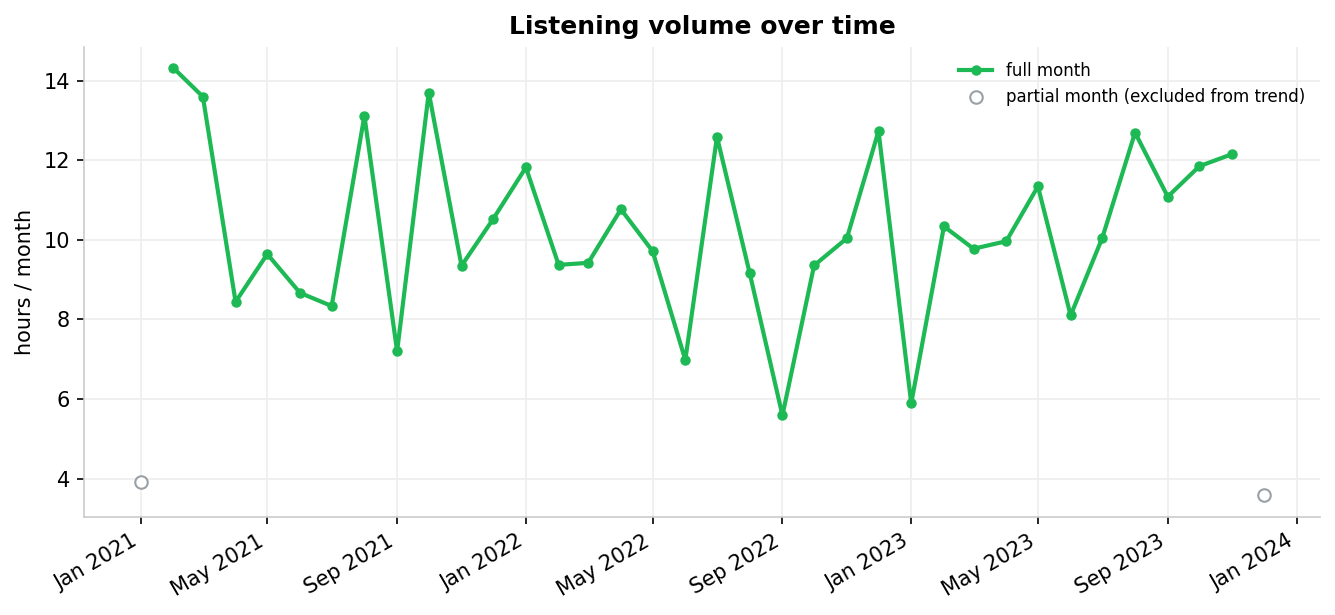

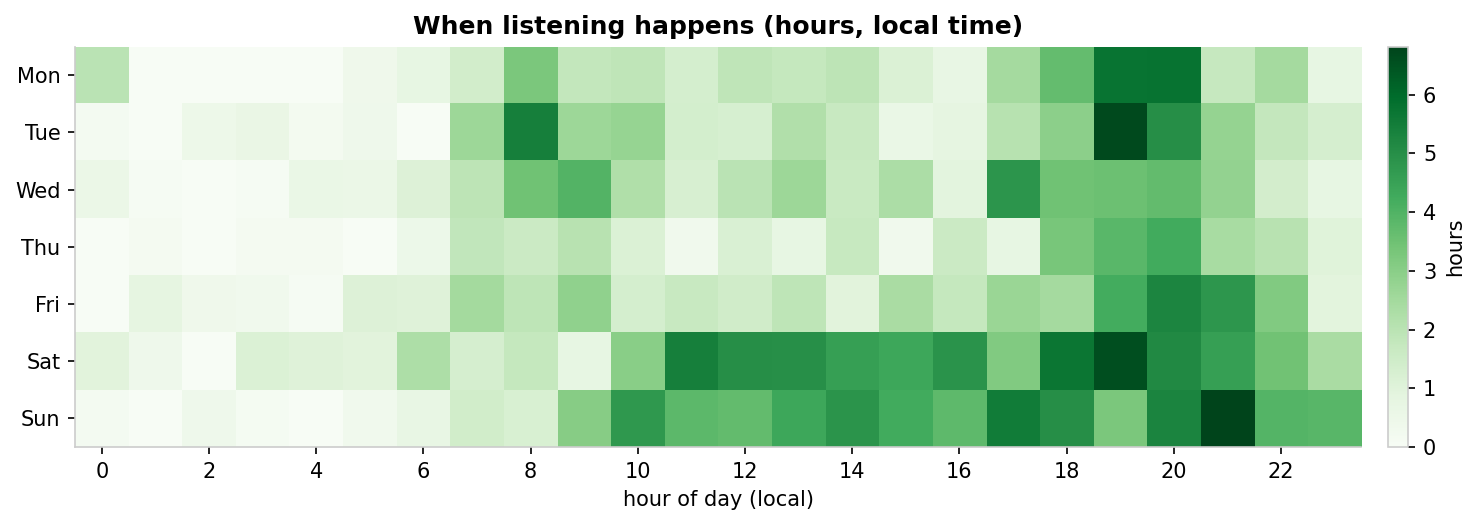

In [5]:
display(Image(filename=str(ROOT / 'figures' / 'volume_trend.png')))
display(Image(filename=str(ROOT / 'figures' / 'hour_dow_heatmap.png')))

## 3. Skip rate — the honest number

Wrapped never shows this. Overall skip rate, then split by shuffle and by
discovery-vs-familiar.

In [6]:
df(con, 'SELECT * FROM skip_overall')

,n_started,n_skips,skip_rate
0,7978,1760.0,0.220607


In [7]:
df(con, 'SELECT * FROM skip_by_shuffle ORDER BY shuffle')

,shuffle,n_started,n_skips,skip_rate
0,False,4400,512.0,0.116364
1,True,3578,1248.0,0.348798


In [8]:
df(con, 'SELECT * FROM skip_by_familiarity ORDER BY familiarity')

,familiarity,n_started,skip_rate
0,discovery,247,0.242915
1,familiar,7731,0.219894


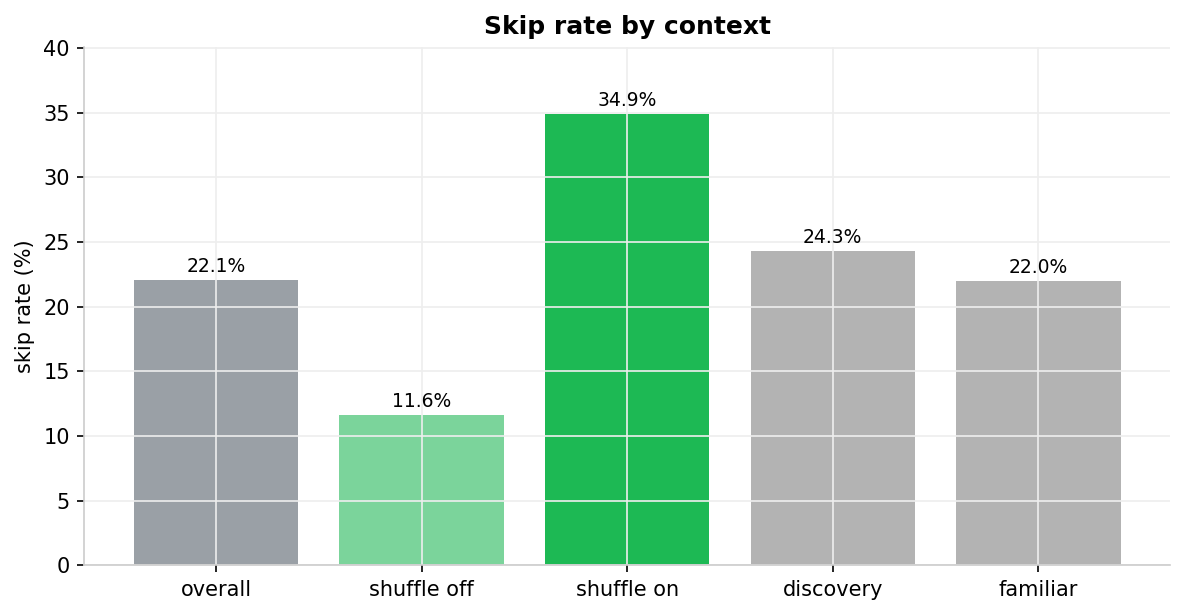

In [9]:
display(Image(filename=str(ROOT / 'figures' / 'skip_breakdown.png')))

## 4. Taste concentration

How monogamous is the taste? Top-1% / top-10% artist share of listening
time, plus the Herfindahl index (HHI) and a Lorenz curve.

In [10]:
df(con, 'SELECT * FROM concentration')

,n_artists,top1_n,top10_n,top1pct_share,top10pct_share,hhi
0,43,1,5,0.22289,0.688711,0.118993


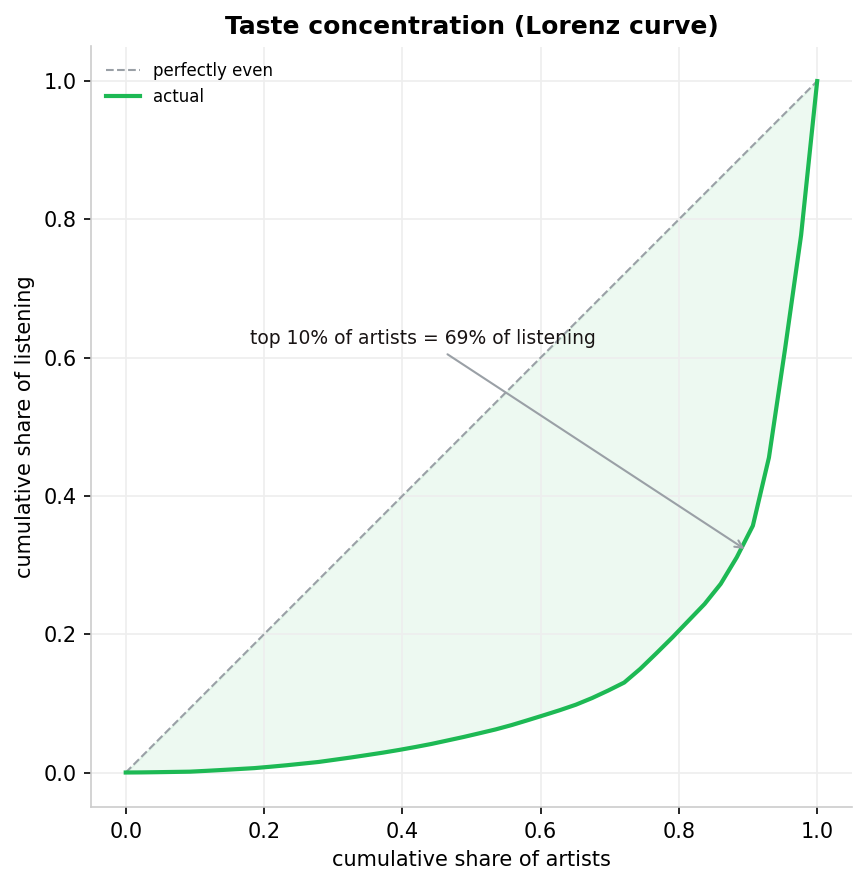

In [11]:
display(Image(filename=str(ROOT / 'figures' / 'concentration.png')))

## 5. Discovery & artist retention

Discovery rate = new artists per month. Retention = the fraction of an
artist *cohort* (grouped by discovery month) still played k months later,
using only fully-observed windows and zero-filled denominators to avoid
survivorship bias (SPEC §6.2).

In [12]:
df(con, 'SELECT * FROM retention_curve ORDER BY k LIMIT 12')

,k,retention,n_cohorts,artists_at_risk
0,0,1.000000,25,43.0
1,1,0.833333,24,42.0
2,2,0.666667,24,42.0
3,3,0.658537,23,41.0
4,4,0.675000,22,40.0
5,5,0.600000,22,40.0
6,6,0.487179,21,39.0
7,7,0.472222,20,36.0
8,8,0.444444,20,36.0
9,9,0.400000,19,35.0


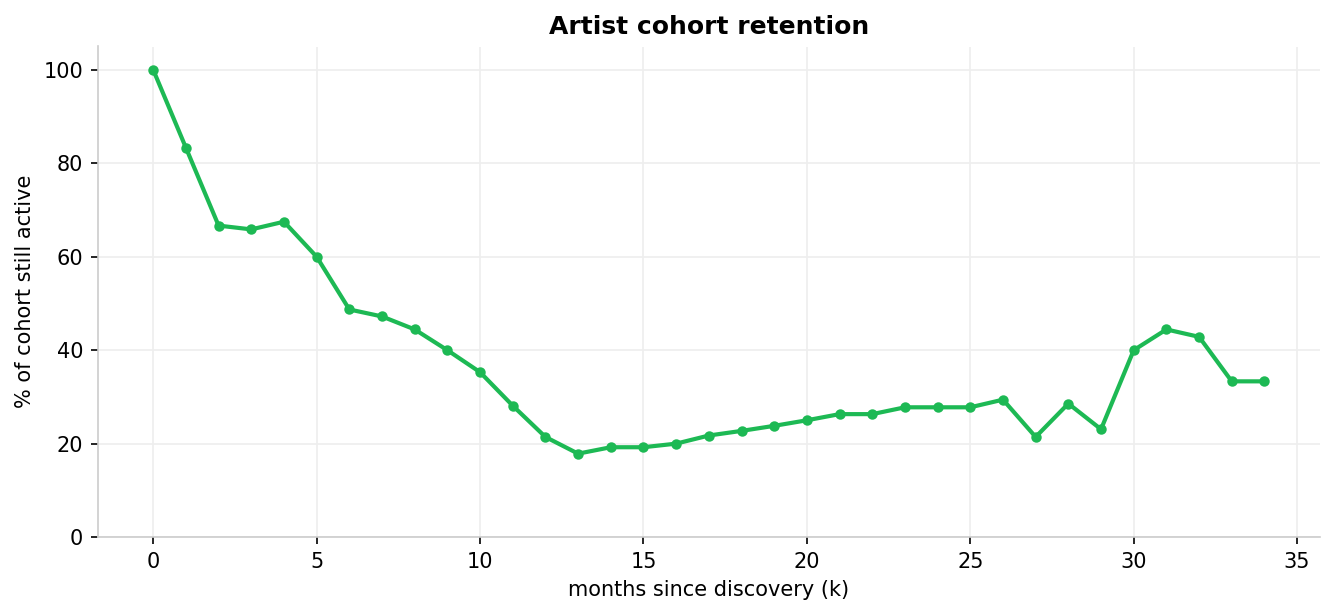

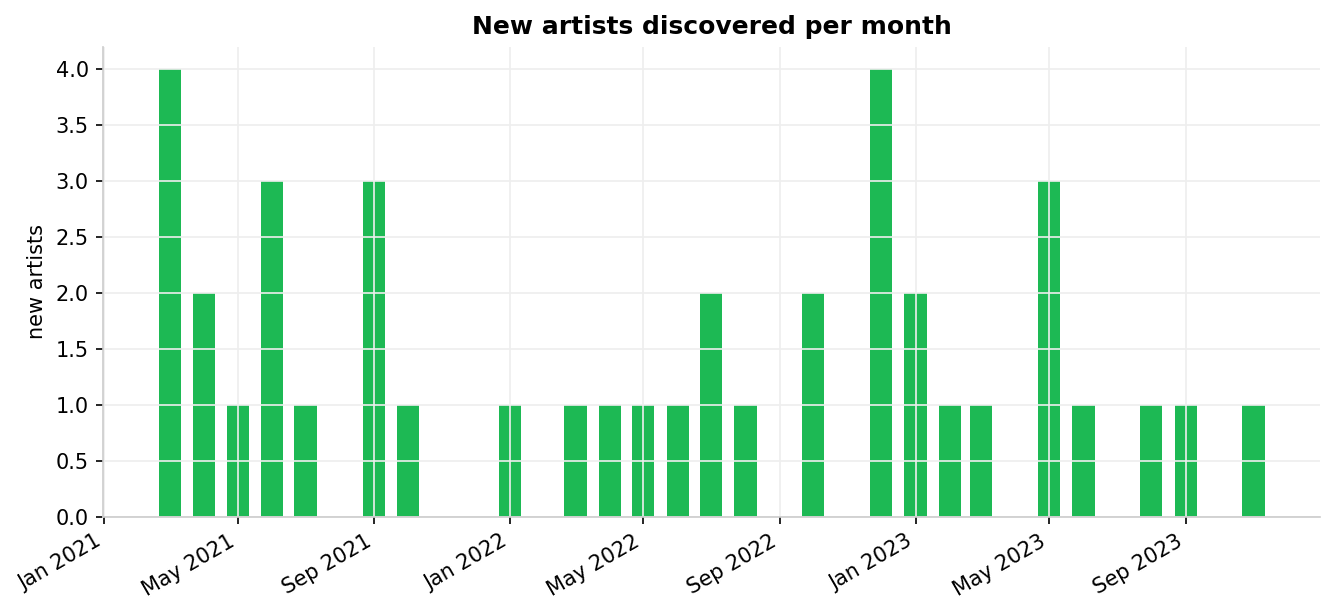

In [13]:
display(Image(filename=str(ROOT / 'figures' / 'cohort_retention.png')))
display(Image(filename=str(ROOT / 'figures' / 'discovery_trend.png')))

## 6. Hypothesis test

**H1: skip rate is higher on shuffle than on intentional plays.**
Two-proportion z-test with an effect size. The caveat matters: plays are
autocorrelated within sessions, so this is descriptive evidence, not a
clean randomized experiment (SPEC §7.3).

In [14]:
h = hypothesis_test(con)
for k, v in h.items():
    print(f'{k:>18}: {v}')

      shuffle_rate: 0.3487982112912241
         shuffle_n: 3578
     shuffle_skips: 1248
  intentional_rate: 0.11636363636363636
     intentional_n: 4400
 intentional_skips: 512
        difference: 0.23243457492758776
                 z: 24.9007575618666
       p_one_sided: 3.6504522892784243e-137
          cohens_h: 0.5673643893576491


## Caveats

- **Synthetic sample.** These numbers come from `data/sample/` (generated
  by `src/generate_sample.py`), not real history. Swap in the real export
  with `python -m src.run_analysis --data data/raw` (SPEC Phase 7).
- **Left-censoring.** Everything heard in the first month looks 'newly
  discovered', so the first month is excluded from the discovery trend.
- **Fixed-offset timezone.** IST has no DST so a fixed +5:30 offset is
  exact here; a DST timezone would need the ICU extension.
- **Autocorrelation.** See the hypothesis-test caveat above.